# DSPy-Style Fixer Agent Prompt Optimization — PubTabNet Dataset

Variant of `dspy_fixer.ipynb` using pre-computed UniTable predictions from `eval_unitable_results/`.
No UniTable inference required — predictions loaded directly from disk.

Key differences from `dspy_fixer.ipynb`:
- **500 available triplets** (image + `_pred.html` + `_gt.html`) vs 13 train images
- **50 train / 20 test** (full) vs 13 / 7
- **No UniTable model load** — predictions already on disk
- **Baseline TEDS** parsed from filename (`TEDS<score>`) instead of re-running scorer

Loop per iteration:
1. Evaluate current best prompt on all train images
2. Collect few-shot examples from high-TEDS training pairs
3. Generate N candidate system prompts in parallel (async, varied meta-temp)
4. Score all candidates on train set (parallelized fixer calls per candidate)
5. Select best by composite score; track diversity

In [13]:
import json
import re
import sys
import random
import base64
import io
import time
import asyncio
import concurrent.futures
import statistics
from pathlib import Path
from datetime import datetime

import nest_asyncio
nest_asyncio.apply()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, HTML
from bs4 import BeautifulSoup
from pydantic import BaseModel

project_root = Path.cwd().parent
huma_root = project_root / 'Huma-Huma'
for p in [project_root, huma_root, huma_root / 'unitable', project_root / 'pubtabnet' / 'src']:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from google.genai import types as genai_types
from metric import TEDS
from shared.client import client, DEFAULT_MODEL, PRO_MODEL

print(f'Model: {PRO_MODEL}')
print('Imports OK')

Model: gemini-3.1-pro-preview
Imports OK


In [14]:
SMOKE_TEST = False

TRAIN_SIZE = 12
TEST_SIZE  = 20

N_CANDIDATES   = 5
MAX_ITERATIONS = 8
TARGET_COMPOSITE = 0.96
PLATEAU_WINDOW   = 3

BETA = 0.5

FEWSHOT_TEDS_THRESHOLD = 0.98
MAX_FEWSHOT_EXAMPLES   = 3

META_TEMPERATURES = [0.7, 0.9, 1.0, 1.1, 1.3]

FIXER_TEMPERATURE = 0.0
EVAL_WORKERS      = 8

MIN_TEDS_FILTER = 0.85   # only train/test on samples where fixer can realistically help

random.seed(42)

print(f"{'[SMOKE TEST]' if SMOKE_TEST else '[FULL RUN]'}")
print(f'Train: {TRAIN_SIZE}, Test: {TEST_SIZE}, Candidates: {N_CANDIDATES}, Max iters: {MAX_ITERATIONS}')
print(f'Composite = mean_TEDS - {BETA} * std_TEDS, target: {TARGET_COMPOSITE}')

[FULL RUN]
Train: 12, Test: 20, Candidates: 5, Max iters: 8
Composite = mean_TEDS - 0.5 * std_TEDS, target: 0.96


## Load eval_unitable_results triplets

In [15]:
EVAL_DIR = project_root / 'eval_unitable_results'

def load_triplets(root: Path) -> list[dict]:
    records = []
    for png in sorted(root.glob('*.png')):
        stem = png.stem
        gt   = root / f'{stem}_gt.html'
        pred = root / f'{stem}_pred.html'
        if not gt.exists() or not pred.exists():
            continue
        teds_baseline = float(stem.split('TEDS')[1])
        records.append({
            'filename':      stem,
            'image_path':    png,
            'gt_html':       gt.read_text(),
            'pred_html':     pred.read_text(),
            'teds_baseline': teds_baseline,
        })
    return records

teds_scorer    = TEDS(structure_only=False)
teds_structure = TEDS(structure_only=True)

all_triplets = load_triplets(EVAL_DIR)
print(f'Loaded {len(all_triplets)} triplets from {EVAL_DIR.name}/')
print(f'Baseline TEDS range: {min(d["teds_baseline"] for d in all_triplets):.3f}'
      f' to {max(d["teds_baseline"] for d in all_triplets):.3f}')

Loaded 500 triplets from eval_unitable_results/
Baseline TEDS range: 0.105 to 0.950


In [16]:
# Debug: verify load_triplets parsed TEDS correctly
print("Sample teds_baseline values from load_triplets:")
for d in all_triplets[:5]:
    raw = d['filename'].split('TEDS')[1]
    print(f"  {d['filename']}  raw='{raw}'  parsed={d['teds_baseline']}")

# Filter to samples where fixer can realistically help
eligible = [d for d in all_triplets if d['teds_baseline'] >= MIN_TEDS_FILTER]
print(f'\nEligible (TEDS >= {MIN_TEDS_FILTER}): {len(eligible)}/{len(all_triplets)}')

if len(eligible) < TRAIN_SIZE + TEST_SIZE:
    raise ValueError(f"Not enough eligible samples ({len(eligible)}) for train ({TRAIN_SIZE}) + test ({TEST_SIZE})")

random.shuffle(eligible)
train_data = eligible[:TRAIN_SIZE]
test_data  = eligible[TRAIN_SIZE:TRAIN_SIZE + TEST_SIZE]

print(f'\nTrain ({len(train_data)}):')
for d in train_data: print(f"  {d['filename']}  (TEDS: {d['teds_baseline']:.3f})")
print(f'\nTest ({len(test_data)}):')
for d in test_data:  print(f"  {d['filename']}  (TEDS: {d['teds_baseline']:.3f})")

# Sanity check
assert all(d['teds_baseline'] >= MIN_TEDS_FILTER for d in train_data + test_data),     "BUG: filtered samples have teds_baseline below threshold!"
baseline_mean = sum(d['teds_baseline'] for d in train_data) / len(train_data)
print(f'\nFilter OK. Train baseline TEDS mean: {baseline_mean:.4f}')


Sample teds_baseline values from load_triplets:
  imgid_548924_TEDS0.911  raw='0.911'  parsed=0.911
  imgid_549416_TEDS0.833  raw='0.833'  parsed=0.833
  imgid_549482_TEDS0.855  raw='0.855'  parsed=0.855
  imgid_549778_TEDS0.600  raw='0.600'  parsed=0.6
  imgid_549838_TEDS0.865  raw='0.865'  parsed=0.865

Eligible (TEDS >= 0.85): 302/500

Train (12):
  imgid_708035_TEDS0.864  (TEDS: 0.864)
  imgid_588407_TEDS0.857  (TEDS: 0.857)
  imgid_709053_TEDS0.880  (TEDS: 0.880)
  imgid_644691_TEDS0.887  (TEDS: 0.887)
  imgid_664752_TEDS0.903  (TEDS: 0.903)
  imgid_697402_TEDS0.864  (TEDS: 0.864)
  imgid_567775_TEDS0.895  (TEDS: 0.895)
  imgid_624997_TEDS0.883  (TEDS: 0.883)
  imgid_567318_TEDS0.929  (TEDS: 0.929)
  imgid_718588_TEDS0.882  (TEDS: 0.882)
  imgid_559527_TEDS0.924  (TEDS: 0.924)
  imgid_688649_TEDS0.944  (TEDS: 0.944)

Test (20):
  imgid_679645_TEDS0.934  (TEDS: 0.934)
  imgid_683989_TEDS0.936  (TEDS: 0.936)
  imgid_637611_TEDS0.922  (TEDS: 0.922)
  imgid_722366_TEDS0.860  (TEDS: 0.

## Core helper functions

In [17]:
def hybrid_extract(image: Image.Image, unitable_html: str, system_prompt: str) -> str:
    if not unitable_html:
        return ''
    buf = io.BytesIO()
    image.save(buf, format='PNG')
    img_bytes = buf.getvalue()
    response = client.models.generate_content(
        model=PRO_MODEL,
        contents=[
            {'inline_data': {'mime_type': 'image/png', 'data': base64.b64encode(img_bytes).decode()}},
            f'Here is the UniTable HTML to correct:\n\n{unitable_html}',
        ],
        config={'system_instruction': system_prompt, 'temperature': FIXER_TEMPERATURE},
    )
    text = response.text.strip()
    if text == 'NO_CHANGES':
        return unitable_html
    text = re.sub(r'^```html\s*', '', text)
    text = re.sub(r'\s*```$', '', text)
    return text


def score_candidate(system_prompt: str, data: list) -> dict:
    per_image = [None] * len(data)

    def _eval_one(args):
        idx, item = args
        image   = Image.open(item['image_path']).convert('RGB')
        ut_html = item['pred_html']
        gt_html = item['gt_html']
        _teds_full   = TEDS(structure_only=False)
        _teds_struct = TEDS(structure_only=True)
        try:
            pred_html = hybrid_extract(image, ut_html, system_prompt)
        except Exception:
            pred_html = ''
        teds_full   = _teds_full.evaluate(pred_html, gt_html)   if pred_html else 0.0
        teds_struct = _teds_struct.evaluate(pred_html, gt_html) if pred_html else 0.0
        return idx, {
            'filename':      item['filename'],
            'teds':          teds_full,
            'struct_teds':   teds_struct,
            'pred_html':     pred_html,
            'gt_html':       gt_html,
            'unitable_html': ut_html,
        }

    with concurrent.futures.ThreadPoolExecutor(max_workers=EVAL_WORKERS) as pool:
        for idx, result in pool.map(_eval_one, enumerate(data)):
            per_image[idx] = result

    scores = [r['teds'] for r in per_image]
    mean_t = statistics.mean(scores)
    std_t  = statistics.stdev(scores) if len(scores) > 1 else 0.0
    return {'mean_teds': mean_t, 'std_teds': std_t,
            'composite': mean_t - BETA * std_t, 'per_image': per_image}


def analyze_errors(eval_result: dict, threshold: float = 0.97) -> str:
    error_lines = []
    for img in eval_result['per_image']:
        if img['teds'] >= threshold:
            continue
        error_lines.append(f"\n### {img['filename']} (TEDS={img['teds']:.3f})")
        pred_cells = [td.get_text(strip=True) for td in BeautifulSoup(img['pred_html'], 'html.parser').find_all('td')]
        gt_cells   = [td.get_text(strip=True) for td in BeautifulSoup(img['gt_html'],   'html.parser').find_all('td')]
        if len(pred_cells) != len(gt_cells):
            error_lines.append(f'  Cell count: predicted {len(pred_cells)}, gt {len(gt_cells)}')
        diffs = 0
        for i in range(min(len(pred_cells), len(gt_cells))):
            if pred_cells[i] != gt_cells[i] and diffs < 15:
                error_lines.append(f"  Cell {i}: pred='{pred_cells[i]}' | gt='{gt_cells[i]}'")
                diffs += 1
        for i in range(len(gt_cells), min(len(pred_cells), len(gt_cells) + 5)):
            error_lines.append(f"  Extra cell {i}: '{pred_cells[i]}'")
        for i in range(len(pred_cells), min(len(gt_cells), len(pred_cells) + 5)):
            error_lines.append(f"  Missing cell {i}: gt='{gt_cells[i]}'")
    return '\n'.join(error_lines) if error_lines else 'All images meet threshold.'


print('hybrid_extract(), score_candidate(), analyze_errors() ready')

hybrid_extract(), score_candidate(), analyze_errors() ready


## Few-shot bootstrap helpers

In [18]:
def collect_fewshot_examples(eval_result: dict, threshold: float = FEWSHOT_TEDS_THRESHOLD) -> list[dict]:
    examples = []
    for img in sorted(eval_result['per_image'], key=lambda x: x['teds'], reverse=True):
        if img['teds'] < threshold:
            break
        if not img['unitable_html'] or not img['pred_html']:
            continue
        examples.append({
            'filename':       img['filename'],
            'unitable_html':  img['unitable_html'],
            'corrected_html': img['pred_html'],
            'teds':           img['teds'],
        })
        if len(examples) >= MAX_FEWSHOT_EXAMPLES:
            break
    return examples


def format_fewshot_block(examples: list[dict]) -> str:
    if not examples:
        return ''
    lines = ['\n## Verified correction examples (use these as reference)\n']
    for i, ex in enumerate(examples, 1):
        lines.append(f'<example_{i}>')
        lines.append(f"<input_html>{ex['unitable_html'][:800]}</input_html>")
        lines.append(f"<corrected_html>{ex['corrected_html'][:800]}</corrected_html>")
        lines.append(f'</example_{i}>\n')
    return '\n'.join(lines)


print('collect_fewshot_examples(), format_fewshot_block() ready')

collect_fewshot_examples(), format_fewshot_block() ready


## Pydantic schemas and META_PROMPT template

In [19]:
class CandidatePrompt(BaseModel):
    system_prompt: str
    rationale: str


META_PROMPT_TEMPLATE = "You are a prompt engineering expert. Generate {n} diverse system prompts for an HTML table OCR correction agent.\n\n## Agent task\nThe agent receives: (1) a table image, (2) its UniTable-extracted HTML as a user message.\nIt must either return corrected HTML (cell text fixes only) or the exact string NO_CHANGES.\n\n## Current best prompt (iteration {iteration})\n{current_prompt}\n\n## Current performance on {n_train} training images\nMean TEDS: {mean_teds:.4f} | Std: {std_teds:.4f} | Composite (mean - {beta}*std): {composite:.4f}\nTarget composite: {target:.3f}\n\n## Error patterns observed\n{error_analysis}\n\n## Few-shot examples available (high-confidence corrections)\n{fewshot_summary}\n\n## Requirements for each of the {n} candidates\n- Open with a role statement identifying the agent as an OCR correction expert for scientific HTML tables\n- Include the NO_CHANGES instruction: if no errors are found, respond with exactly NO_CHANGES\n- Otherwise return ONLY corrected HTML \u2014 no markdown fences, no explanations\n- Do NOT modify structure (rowspan, colspan, <tr>, <th>, <td> tags)\n- Under 500 words if no few-shots; under 700 words if few-shots are included\n- Candidates must be meaningfully different from each other \u2014 vary your strategies\n- If few-shot examples are provided, at least one candidate should incorporate them verbatim\n\nStrategy variation ideas: conservative vs aggressive correction, emphasis on numeric precision,\nemphasis on scientific symbols, emphasis on case/formatting, use of few-shot examples.\n"

print('CandidatePrompt schema and META_PROMPT_TEMPLATE ready')

CandidatePrompt schema and META_PROMPT_TEMPLATE ready


## Async candidate generation

In [20]:
async def generate_one_candidate(meta_prompt: str, temperature: float) -> CandidatePrompt | None:
    try:
        response = await client.aio.models.generate_content(
            model=DEFAULT_MODEL,
            contents=[meta_prompt],
            config=genai_types.GenerateContentConfig(
                response_mime_type='application/json',
                response_schema=CandidatePrompt,
                temperature=temperature,
            ),
        )
        return CandidatePrompt.model_validate_json(response.text)
    except Exception as e:
        print(f'  [meta-prompt ERROR at T={temperature}]: {e}')
        return None


async def generate_candidates_async(meta_prompt: str) -> list[CandidatePrompt]:
    tasks = [
        generate_one_candidate(meta_prompt, temp)
        for temp in META_TEMPERATURES[:N_CANDIDATES]
    ]
    results = await asyncio.gather(*tasks)
    return [r for r in results if r is not None]


def generate_candidates(meta_prompt: str) -> list[CandidatePrompt]:
    return asyncio.run(generate_candidates_async(meta_prompt))


print('Async candidate generation ready')

Async candidate generation ready


## Diversity tracking via prompt embeddings

In [21]:
def compute_candidate_diversity(candidates: list[CandidatePrompt]) -> float:
    if len(candidates) < 2:
        return 1.0
    embeddings = []
    for cand in candidates:
        resp = client.models.embed_content(
            model='gemini-embedding-001',
            contents=cand.system_prompt,
        )
        embeddings.append(resp.embeddings[0].values)
    emb = np.array(embeddings)
    emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-9)
    sim = emb @ emb.T
    n = len(candidates)
    pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]
    mean_sim = sum(sim[i, j] for i, j in pairs) / len(pairs)
    return float(mean_sim)

print('compute_candidate_diversity() ready (gemini-embedding-001)')

compute_candidate_diversity() ready (gemini-embedding-001)


## History tracker

In [22]:
iteration_history = []

def record_iteration(iteration, candidates, eval_results, best_idx, fewshot_examples, diversity_score):
    iteration_history.append({
        'iteration':      iteration,
        'n_candidates':   len(candidates),
        'best_idx':       best_idx,
        'best_composite': eval_results[best_idx]['composite'],
        'best_mean_teds': eval_results[best_idx]['mean_teds'],
        'best_std_teds':  eval_results[best_idx]['std_teds'],
        'all_composites': [r['composite'] for r in eval_results],
        'all_mean_teds':  [r['mean_teds']  for r in eval_results],
        'best_prompt':    candidates[best_idx].system_prompt,
        'best_rationale': candidates[best_idx].rationale,
        'n_fewshot':      len(fewshot_examples),
        'diversity':      diversity_score,
        'timestamp':      datetime.now().isoformat(),
    })

def show_history():
    rows = [{
        'iter':       h['iteration'],
        'composite':  round(h['best_composite'], 4),
        'mean_teds':  round(h['best_mean_teds'], 4),
        'std_teds':   round(h['best_std_teds'],  4),
        'diversity':  round(h['diversity'],       3),
        'n_fewshot':  h['n_fewshot'],
        'candidates': str([round(c, 3) for c in h['all_composites']]),
    } for h in iteration_history]
    display(pd.DataFrame(rows))

print('History tracker ready')

History tracker ready


## Seed prompt

Best prompt from `dspy_fixer.ipynb` full run (test TEDS: 0.967, hallucination-aware).

In [23]:
current_best_prompt = "You are a high-precision OCR Correction Expert for scientific tables. Your priority is identifying and fixing 'hallucination' errors where the OCR model repeats the same text across multiple cells incorrectly, a common failure in complex table extractions.\n\nInstructions:\n1. Compare the text in each cell of the provided HTML against the table image.\n2. Correct any misread numbers, letters, or symbols.\n3. Ensure case sensitivity and scientific notation (\u00b1, \u2264, \u2265, Greek letters) are exact.\n4. If the OCR has repeated a specific phrase (e.g., '95% CI') across cells where the image clearly shows different data (like 'Variable', 'Male', 'Female'), replace the text with the actual values from the image.\n\nMandatory Constraints:\n- Return ONLY the corrected HTML string.\n- No markdown code blocks (no ```html), no preamble, no postscript.\n- DO NOT change the table structure (rows, columns, colspan, or rowspan attributes).\n- If no text corrections are required, respond ONLY with: NO_CHANGES\n"

fewshot_examples: list[dict] = []
print(f'Seed prompt: {len(current_best_prompt.split())} words')
print('(best prompt from dspy_fixer full run, test TEDS: 0.967)')

Seed prompt: 154 words
(best prompt from dspy_fixer full run, test TEDS: 0.967)


## Main optimization loop

In [24]:
plateau_counter      = 0
best_ever_composite  = 0.0
best_ever_prompt     = current_best_prompt

for iteration in range(MAX_ITERATIONS):
    print(f"\n{'='*72}")
    print(f'ITERATION {iteration}  ({N_CANDIDATES} candidates, {TRAIN_SIZE} train images)')
    print(f"{'='*72}")

    print(f'\n[1/5] Evaluating current best prompt on {TRAIN_SIZE} images...')
    current_eval = score_candidate(current_best_prompt, train_data)
    print(f"      mean={current_eval['mean_teds']:.4f}  std={current_eval['std_teds']:.4f}  composite={current_eval['composite']:.4f}")

    fewshot_examples = collect_fewshot_examples(current_eval)
    fewshot_block    = format_fewshot_block(fewshot_examples)
    print(f'\n[2/5] Few-shot examples: {len(fewshot_examples)} collected (threshold={FEWSHOT_TEDS_THRESHOLD})')

    error_analysis = analyze_errors(current_eval, threshold=0.97)
    meta_prompt = META_PROMPT_TEMPLATE.format(
        n=N_CANDIDATES, iteration=iteration,
        current_prompt=current_best_prompt,
        n_train=TRAIN_SIZE,
        mean_teds=current_eval['mean_teds'],
        std_teds=current_eval['std_teds'],
        composite=current_eval['composite'],
        beta=BETA, target=TARGET_COMPOSITE,
        error_analysis=error_analysis[:1500],
        fewshot_summary=fewshot_block[:600] if fewshot_examples else 'None yet.',
    )
    print(f'\n[3/5] Generating {N_CANDIDATES} candidates (async, T={META_TEMPERATURES[:N_CANDIDATES]})...')
    candidates = generate_candidates(meta_prompt)
    print(f'      {len(candidates)} candidates generated')
    for ci, c in enumerate(candidates):
        print(f'      [{ci}] {len(c.system_prompt.split())} words — {c.rationale[:80]}')

    if not candidates:
        print('      No candidates generated. Stopping.')
        break

    print(f'\n[4/5] Scoring {len(candidates)} candidates on {TRAIN_SIZE} train images...')
    candidate_evals = []
    for ci, cand in enumerate(candidates):
        print(f'      Candidate {ci}: ', end='', flush=True)
        ev = score_candidate(cand.system_prompt, train_data)
        candidate_evals.append(ev)
        print(f"composite={ev['composite']:.4f}  (mean={ev['mean_teds']:.4f}, std={ev['std_teds']:.4f})")

    best_idx  = max(range(len(candidate_evals)), key=lambda i: candidate_evals[i]['composite'])
    best_eval = candidate_evals[best_idx]
    best_cand = candidates[best_idx]
    print(f"\n[5/5] Best: candidate {best_idx}  composite={best_eval['composite']:.4f}")
    print(f'      Rationale: {best_cand.rationale}')

    diversity = compute_candidate_diversity(candidates)
    collapse  = diversity > 0.95
    print(f'      Diversity (mean cosine sim): {diversity:.3f}  '
          f"{'WARNING: LOW' if collapse else 'OK'}")

    record_iteration(iteration, candidates, candidate_evals, best_idx, fewshot_examples, diversity)

    if best_eval['composite'] > best_ever_composite:
        best_ever_composite = best_eval['composite']
        best_ever_prompt    = best_cand.system_prompt
        plateau_counter     = 0
        print(f'      New best-ever composite: {best_ever_composite:.4f}')
    else:
        plateau_counter += 1
        print(f'      Plateau counter: {plateau_counter}/{PLATEAU_WINDOW}')

    current_best_prompt = best_cand.system_prompt

    if best_eval['composite'] >= TARGET_COMPOSITE:
        print(f"\n  TARGET REACHED ({best_eval['composite']:.4f} >= {TARGET_COMPOSITE}). Stopping.")
        break
    if plateau_counter >= PLATEAU_WINDOW:
        print(f'\n  PLATEAU ({plateau_counter} iterations without improvement). Stopping.')
        break

    show_history()

print(f"\n{'='*72}")
print('OPTIMIZATION COMPLETE')
print(f'Best composite: {best_ever_composite:.4f}')
print(f"{'='*72}")
show_history()


ITERATION 0  (5 candidates, 12 train images)

[1/5] Evaluating current best prompt on 12 images...
      mean=0.7618  std=0.0809  composite=0.7213

[2/5] Few-shot examples: 0 collected (threshold=0.98)

[3/5] Generating 5 candidates (async, T=[0.7, 0.9, 1.0, 1.1, 1.3])...
      5 candidates generated
      [0] 154 words — This is the original baseline prompt provided in the instructions, serving as th
      [1] 154 words — This candidate addresses the 'shifting' error observed in the logs (where cell i
      [2] 160 words — This prompt specifically targets the 'alignment shift' error observed in the tra
      [3] 36 words — The 5 candidates address different failure modes observed in the training logs. 
      [4] 34 words — I developed these five candidates based on the observed error patterns. (1) 'The

[4/5] Scoring 5 candidates on 12 train images...
      Candidate 0: composite=0.6432  (mean=0.7147, std=0.1429)
      Candidate 1: composite=0.6566  (mean=0.7475, std=0.1818)
      Ca

,iter,composite,mean_teds,std_teds,diversity,n_fewshot,candidates
0,0,0.6756,0.7633,0.1754,0.836,0,"[0.643, 0.657, 0.592, 0.61, 0.676]"



ITERATION 1  (5 candidates, 12 train images)

[1/5] Evaluating current best prompt on 12 images...
      mean=0.7614  std=0.2021  composite=0.6603

[2/5] Few-shot examples: 1 collected (threshold=0.98)

[3/5] Generating 5 candidates (async, T=[0.7, 0.9, 1.0, 1.1, 1.3])...
      5 candidates generated
      [0] 141 words — This prompt focuses on 'text migration'—the idea that misalignment often manifes
      [1] 104 words — This prompt focuses on the 'cell-shift' error pattern observed in the training i
      [2] 89 words — This prompt emphasizes a conservative approach focused on precision and the 'NO_
      [3] 34 words — The strategy for these five prompts involves varying the 'Correction Intensity' 
      [4] 159 words — Prompt 1 focuses on structural preservation and specific scientific symbol corre

[4/5] Scoring 5 candidates on 12 train images...
      Candidate 0: composite=0.6343  (mean=0.7084, std=0.1482)
      Candidate 1: composite=0.6523  (mean=0.7379, std=0.1711)
      Ca

,iter,composite,mean_teds,std_teds,diversity,n_fewshot,candidates
0,0,0.6756,0.7633,0.1754,0.836,0,"[0.643, 0.657, 0.592, 0.61, 0.676]"
1,1,0.6907,0.7878,0.1941,0.880,1,"[0.634, 0.652, 0.679, 0.691, 0.645]"



ITERATION 2  (5 candidates, 12 train images)

[1/5] Evaluating current best prompt on 12 images...
      mean=0.7701  std=0.1839  composite=0.6782

[2/5] Few-shot examples: 1 collected (threshold=0.98)

[3/5] Generating 5 candidates (async, T=[0.7, 0.9, 1.0, 1.1, 1.3])...
      5 candidates generated
      [0] 34 words — The 5 prompts are designed to address the specific failure modes identified: cel
      [1] 107 words — This prompt focuses on 'The Strict Auditor' approach, emphasizing the preservati
      [2] 151 words — This prompt focuses on spatial alignment and cell-shifting errors observed in th
      [3] 116 words — This prompt focuses on 'text shifting' which was a primary error pattern in the 
      [4] 124 words — This prompt uses a high-precision strategy focused on statistical notations and 

[4/5] Scoring 5 candidates on 12 train images...
      Candidate 0: composite=0.6708  (mean=0.7627, std=0.1838)
      Candidate 1: composite=0.6777  (mean=0.7376, std=0.1198)
      C

...

,iter,composite,mean_teds,std_teds,diversity,n_fewshot,candidates
0,0,0.6756,0.7633,0.1754,0.836,0,"[0.643, 0.657, 0.592, 0.61, 0.676]"
1,1,0.6907,0.7878,0.1941,0.880,1,"[0.634, 0.652, 0.679, 0.691, 0.645]"
2,2,0.7209,0.7608,0.0798,0.887,1,"[0.671, 0.678, 0.594, 0.601, 0.721]"
3,3,0.7210,0.7608,0.0797,0.930,0,"[0.629, 0.642, 0.721, 0.671, 0.687]"
4,4,0.7617,0.8070,0.0906,0.944,0,"[0.721, 0.65, 0.728, 0.75, 0.762]"
5,5,0.7213,0.7619,0.0811,0.935,0,"[0.721, 0.66, 0.589, 0.667, 0.626]"



ITERATION 6  (5 candidates, 12 train images)

[1/5] Evaluating current best prompt on 12 images...
      mean=0.7207  std=0.1501  composite=0.6456

[2/5] Few-shot examples: 0 collected (threshold=0.98)

[3/5] Generating 5 candidates (async, T=[0.7, 0.9, 1.0, 1.1, 1.3])...
  [meta-prompt ERROR at T=0.9]: 1 validation error for CandidatePrompt
  Invalid JSON: EOF while parsing a string at line 3 column 305668 [type=json_invalid, input_value='{\n  "system_prompt": "C...now today for this task', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/json_invalid
      4 candidates generated
      [0] 14 words — I have developed five distinct system prompts targeting different failure modes 
      [1] 152 words — Strategy 1: Spatial Mapping & Precision. This candidate focuses on the 'mapping'
      [2] 97 words — This prompt emphasizes 'spatial counterparts' to address the alignment and cell-
      [3] 118 words — This candidate focuses on 'spatial alignment' 

,iter,composite,mean_teds,std_teds,diversity,n_fewshot,candidates
0,0,0.6756,0.7633,0.1754,0.836,0,"[0.643, 0.657, 0.592, 0.61, 0.676]"
1,1,0.6907,0.7878,0.1941,0.880,1,"[0.634, 0.652, 0.679, 0.691, 0.645]"
2,2,0.7209,0.7608,0.0798,0.887,1,"[0.671, 0.678, 0.594, 0.601, 0.721]"
3,3,0.7210,0.7608,0.0797,0.930,0,"[0.629, 0.642, 0.721, 0.671, 0.687]"
4,4,0.7617,0.8070,0.0906,0.944,0,"[0.721, 0.65, 0.728, 0.75, 0.762]"
5,5,0.7213,0.7619,0.0811,0.935,0,"[0.721, 0.66, 0.589, 0.667, 0.626]"
6,6,0.7212,0.7617,0.0810,0.874,0,"[0.669, 0.662, 0.638, 0.721]"



ITERATION 7  (5 candidates, 12 train images)

[1/5] Evaluating current best prompt on 12 images...
      mean=0.7616  std=0.0810  composite=0.7211

[2/5] Few-shot examples: 0 collected (threshold=0.98)

[3/5] Generating 5 candidates (async, T=[0.7, 0.9, 1.0, 1.1, 1.3])...
      5 candidates generated
      [0] 143 words — This prompt focuses on structural integrity to address the 'missing cell' and 't
      [1] 118 words — This initial prompt provides the baseline instructions. It covers the core requi
      [2] 118 words — This prompt (Iteration 7) provides a strong foundation with explicit constraints
      [3] 29 words — The strategy for these five candidates focuses on addressing the observed 'cell 
      [4] 137 words — This prompt focuses on 'Visual Anchoring' to address the cell-shifting error obs

[4/5] Scoring 5 candidates on 12 train images...
      Candidate 0: composite=0.7212  (mean=0.7617, std=0.0810)
      Candidate 1: composite=0.6425  (mean=0.7248, std=0.1646)
      C

,iter,composite,mean_teds,std_teds,diversity,n_fewshot,candidates
0,0,0.6756,0.7633,0.1754,0.836,0,"[0.643, 0.657, 0.592, 0.61, 0.676]"
1,1,0.6907,0.7878,0.1941,0.880,1,"[0.634, 0.652, 0.679, 0.691, 0.645]"
2,2,0.7209,0.7608,0.0798,0.887,1,"[0.671, 0.678, 0.594, 0.601, 0.721]"
3,3,0.7210,0.7608,0.0797,0.930,0,"[0.629, 0.642, 0.721, 0.671, 0.687]"
4,4,0.7617,0.8070,0.0906,0.944,0,"[0.721, 0.65, 0.728, 0.75, 0.762]"
5,5,0.7213,0.7619,0.0811,0.935,0,"[0.721, 0.66, 0.589, 0.667, 0.626]"
6,6,0.7212,0.7617,0.0810,0.874,0,"[0.669, 0.662, 0.638, 0.721]"
7,7,0.7212,0.7617,0.0810,0.899,0,"[0.721, 0.643, 0.721, 0.675, 0.588]"


## Visualization: composite score trajectory and candidate diversity

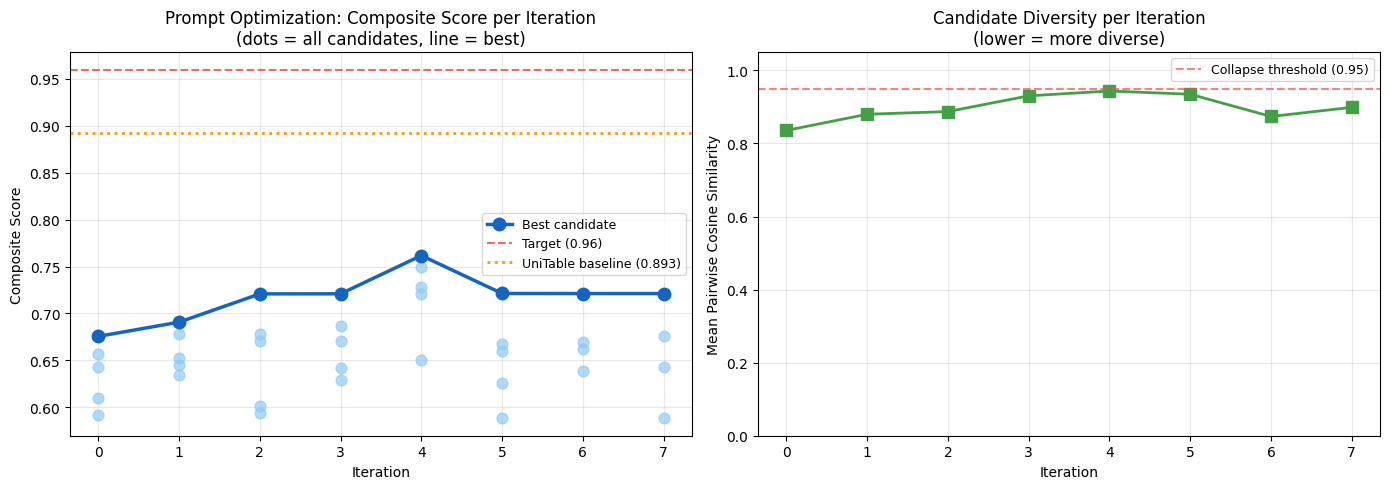

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

iters           = [h['iteration']      for h in iteration_history]
best_composites = [h['best_composite'] for h in iteration_history]
diversities     = [h['diversity']      for h in iteration_history]

for h in iteration_history:
    ax1.scatter([h['iteration']] * len(h['all_composites']), h['all_composites'],
                color='#90CAF9', s=60, zorder=2, alpha=0.7, label='_')
ax1.plot(iters, best_composites, 'o-', color='#1565C0', linewidth=2.5,
         markersize=9, label='Best candidate', zorder=3)
ax1.axhline(TARGET_COMPOSITE, color='#F44336', linestyle='--', linewidth=1.5,
            alpha=0.8, label=f'Target ({TARGET_COMPOSITE})')

ut_baseline = sum(d['teds_baseline'] for d in train_data) / len(train_data)
ax1.axhline(ut_baseline, color='#FF9800', linestyle=':', linewidth=2,
            label=f'UniTable baseline ({ut_baseline:.3f})')

ax1.set_xlabel('Iteration'); ax1.set_ylabel('Composite Score')
ax1.set_title('Prompt Optimization: Composite Score per Iteration\n(dots = all candidates, line = best)')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

ax2.plot(iters, diversities, 's-', color='#43A047', linewidth=2, markersize=8)
ax2.axhline(0.95, color='#EF5350', linestyle='--', linewidth=1.5,
            alpha=0.7, label='Collapse threshold (0.95)')
ax2.set_xlabel('Iteration'); ax2.set_ylabel('Mean Pairwise Cosine Similarity')
ax2.set_title('Candidate Diversity per Iteration\n(lower = more diverse)')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3); ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## Candidate comparison at best iteration

In [26]:
best_iter = max(iteration_history, key=lambda h: h['best_composite'])
print(f"Best iteration: {best_iter['iteration']}  composite={best_iter['best_composite']:.4f}")
print(f"Rationale: {best_iter['best_rationale']}")
print(f"Few-shot examples used: {best_iter['n_fewshot']}")
print()
rows = [{'candidate': i, 'composite': round(c, 4), 'mean_teds': round(m, 4)}
        for i, (c, m) in enumerate(zip(best_iter['all_composites'], best_iter['all_mean_teds']))]
display(pd.DataFrame(rows))

Best iteration: 4  composite=0.7617
Rationale: I generated 5 diverse prompts covering different strategies: a 'Precision Guardian' focus on symbol accuracy, a 'Structural Alignment' focus addressing cell-shifting errors, a 'Symbol-Centric' approach for scientific notation, a 'Format-First' approach emphasizing the removal of markdown, and a 'Heuristic-Based' approach that explicitly mentions the observed error types. Each prompt reinforces the NO_CHANGES trigger and the absolute ban on structural modifications.
Few-shot examples used: 0



,candidate,composite,mean_teds
0,0,0.7209,0.7608
1,1,0.6504,0.7275
2,2,0.7280,0.7691
3,3,0.7499,0.7851
4,4,0.7617,0.8070


## Validate best prompt on held-out test set

In [27]:
print(f'Evaluating best prompt on {len(test_data)} held-out test images...')
test_eval = score_candidate(best_ever_prompt, test_data)

print(f"\n{'='*60}")
print('TEST SET RESULTS')
print(f"{'='*60}")
print(f"  Mean TEDS:   {test_eval['mean_teds']:.4f}")
print(f"  Std TEDS:    {test_eval['std_teds']:.4f}")
print(f"  Composite:   {test_eval['composite']:.4f}")
print(f'  Train comp.: {best_ever_composite:.4f}')
gap = best_ever_composite - test_eval['composite']
print(f"  Gap:         {gap:+.4f}  {'WARNING: possible overfit' if gap > 0.05 else 'OK'}")

Evaluating best prompt on 20 held-out test images...

TEST SET RESULTS
  Mean TEDS:   0.7803
  Std TEDS:    0.1104
  Composite:   0.7251
  Train comp.: 0.7617
  Gap:         +0.0367  OK


## Baseline comparison: UniTable-only vs best hybrid (test set)

In [28]:
rows = []
for item in test_data:
    hy = next((r for r in test_eval['per_image'] if r['filename'] == item['filename']), None)
    hy_teds   = hy['teds']        if hy else 0.0
    hy_struct = hy['struct_teds'] if hy else 0.0
    rows.append({
        'filename':      item['filename'],
        'UniTable TEDS': round(item['teds_baseline'], 3),
        'Hybrid TEDS':   round(hy_teds, 3),
        'Hybrid Struct': round(hy_struct, 3),
        'Delta':         round(hy_teds - item['teds_baseline'], 3),
    })

df = pd.DataFrame(rows)
display(df)

ut_mean = df['UniTable TEDS'].mean()
hy_mean = df['Hybrid TEDS'].mean()
print(f'\nTest set aggregates:')
print(f'  UniTable-only: {ut_mean:.3f} mean TEDS')
print(f'  Best hybrid:   {hy_mean:.3f} mean TEDS')
print(f'  Improvement:   {hy_mean - ut_mean:+.3f}')

,filename,UniTable TEDS,Hybrid TEDS,Hybrid Struct,Delta
0,imgid_679645_TEDS0.934,0.934,0.827,0.934,-0.107
1,imgid_683989_TEDS0.936,0.936,0.904,0.936,-0.032
2,imgid_637611_TEDS0.922,0.922,0.906,0.922,-0.016
3,imgid_722366_TEDS0.860,0.860,0.624,0.860,-0.236
4,imgid_552517_TEDS0.912,0.912,0.724,0.912,-0.188
5,imgid_610901_TEDS0.881,0.881,0.749,0.881,-0.132
6,imgid_638844_TEDS0.930,0.930,0.763,0.930,-0.167
7,imgid_657572_TEDS0.920,0.920,0.838,0.920,-0.082
8,imgid_561731_TEDS0.923,0.923,0.902,0.923,-0.021
9,imgid_699302_TEDS0.856,0.856,0.578,0.856,-0.278



Test set aggregates:
  UniTable-only: 0.906 mean TEDS
  Best hybrid:   0.780 mean TEDS
  Improvement:   -0.126


In [29]:
print("=" * 72)
print("FIXER DIAGNOSTIC: What is the fixer actually doing?")
print("=" * 72)

no_change_count = 0
helped = []
hurt   = []
struct_violations = []

for item in test_data:
    r = next((x for x in test_eval['per_image'] if x['filename'] == item['filename']), None)
    if r is None:
        continue

    baseline = item['teds_baseline']
    hybrid   = r['teds']
    delta    = hybrid - baseline
    changed  = r['pred_html'].strip() != item['pred_html'].strip()

    if not changed:
        no_change_count += 1

    if delta > 0.001:
        helped.append((item['filename'], baseline, hybrid, delta))
    elif delta < -0.001:
        hurt.append((item['filename'], baseline, hybrid, delta))

    # Structure check: did fixer change colspan/rowspan?
    if changed:
        pred_soup = BeautifulSoup(r['pred_html'], 'html.parser')
        base_soup = BeautifulSoup(item['pred_html'], 'html.parser')
        pred_spans = [(t.get('colspan','1'), t.get('rowspan','1')) for t in pred_soup.find_all(['td','th'])]
        base_spans = [(t.get('colspan','1'), t.get('rowspan','1')) for t in base_soup.find_all(['td','th'])]
        if pred_spans != base_spans:
            struct_violations.append(item['filename'])

n = len(test_data)
print(f"\nNO_CHANGES rate:     {no_change_count}/{n} ({100*no_change_count/n:.0f}%)")
print(f"Made changes:        {n - no_change_count}/{n} ({100*(n-no_change_count)/n:.0f}%)")
print(f"  → Helped (delta>0): {len(helped)}")
print(f"  → Hurt  (delta<0): {len(hurt)}")
print(f"Structure violations: {len(struct_violations)}")

if struct_violations:
    print("\nSTRUCTURE CHANGED (colspan/rowspan modified — fixer violated constraints):")
    for fn in struct_violations:
        print(f"  {fn}")

if hurt:
    print("\nWorst regressions (fixer made things WORSE):")
    for fn, base, hyb, d in sorted(hurt, key=lambda x: x[3])[:5]:
        r = next(x for x in test_eval['per_image'] if x['filename'] == fn)
        pred_cells = [td.get_text(strip=True) for td in BeautifulSoup(r['pred_html'], 'html.parser').find_all('td')]
        base_cells = [td.get_text(strip=True) for td in BeautifulSoup(r['unitable_html'], 'html.parser').find_all('td')]
        diffs = [(i, base_cells[i], pred_cells[i]) for i in range(min(len(base_cells), len(pred_cells))) if base_cells[i] != pred_cells[i]]
        print(f"\n  {fn}  baseline={base:.3f} → hybrid={hyb:.3f}  (delta={d:+.3f})")
        for i, before, after in diffs[:5]:
            print(f"    cell {i}: '{before}' → '{after}'")


FIXER DIAGNOSTIC: What is the fixer actually doing?

NO_CHANGES rate:     0/20 (0%)
Made changes:        20/20 (100%)
  → Helped (delta>0): 0
  → Hurt  (delta<0): 20
Structure violations: 1

STRUCTURE CHANGED (colspan/rowspan modified — fixer violated constraints):
  imgid_666184_TEDS0.947

Worst regressions (fixer made things WORSE):

  imgid_699302_TEDS0.856  baseline=0.856 → hybrid=0.578  (delta=-0.278)
    cell 1: 'Mean visits ( 95 % CI )' → 'Mean visits (95% CI)'
    cell 5: '12.7 ( 10.8 – 14.5 )' → '12.7 (10.8–14.5)'
    cell 8: '13.8 ( 3.6 – 24.1 )' → '13.8 (3.6–24.1)'
    cell 9: 'Age ( years )' → 'Age (years)'
    cell 10: '≥ 60' → '≥60'

  imgid_722366_TEDS0.860  baseline=0.860 → hybrid=0.624  (delta=-0.236)
    cell 3: 'Black - African' → 'Black-African'
    cell 9: 'Black - Caribbean' → 'Black-Caribbean'
    cell 18: 'Region of birth *' → 'Region of birth*'
    cell 31: 'South - East Asia' → 'South-East Asia'
    cell 40: 'Probable route of infection †' → 'Probable route of

## Prompt evolution across iterations

In [30]:
for h in iteration_history:
    print(f"\n{'='*72}")
    print(f"Iteration {h['iteration']} | Composite: {h['best_composite']:.4f} | "
          f"Words: {len(h['best_prompt'].split())} | Few-shots: {h['n_fewshot']}")
    print(f"Rationale: {h['best_rationale']}")
    print(f"{'='*72}")
    print(h['best_prompt'][:500])
    if len(h['best_prompt']) > 500:
        print('...')


Iteration 0 | Composite: 0.6756 | Words: 34 | Few-shots: 0
Rationale: I developed these five candidates based on the observed error patterns. (1) 'The Alignment Auditor' focuses on the shifting issue where text is assigned to the wrong cell index. (2) 'The Mathematical Precise' prioritizes Greek letters, symbols, and numeric separators often missed in LaTeX-to-HTML conversions. (3) 'The Contextual Validator' uses headers to determine if the data in a column logically follows the expected type (e.g., OR, CI). (4) 'The Structural Anchor' strictly enforces row-wise verification to prevent text from migrating vertically. (5) 'The Sparse Data Specialist' targets the specific error in the logs where empty cells are filled with adjacent data, leading to a count mismatch despite the structural constraint.",

[
{
"system_prompt": "You are a high-precision OCR Correction Expert for scientific tables. Your task is to ensure the text content within each HTML <td> or <th> tag perfectly matches its

## Export best prompt

In [31]:
print('=' * 72)
print('FINAL BEST FIXER SYSTEM PROMPT')
print(f"Train composite: {best_ever_composite:.4f} | Test mean TEDS: {test_eval['mean_teds']:.4f}")
print('=' * 72)
print()
print(best_ever_prompt)

FINAL BEST FIXER SYSTEM PROMPT
Train composite: 0.7617 | Test mean TEDS: 0.7803

You are a specialized OCR correction expert for scientific HTML tables. Your mission is to reconcile noisy UniTable extractions with table images to ensure 100% textual accuracy while strictly preserving the provided HTML skeleton.
